# Structural Sources of Real-vs-Synthetic Separability

**Structural recovery test:** Do Graphical Lasso errors explain RF distinguishability?

**Purpose:** Test whether real-vs-synthetic separability is reduced when synthetic data are forced to recover the real conditional-dependence structure while preserving synthetic marginal distributions.

The main notebook establishes two observations: (1) a random forest can distinguish real from synthetic rows, and (2) Graphical Lasso finds conditional-dependence errors. This notebook tests whether those observations are functionally connected.

## Experimental logic

For one fixed real/synthetic dataset pair:

1. Fit real and synthetic Graphical Lasso models to the complete matrices.
2. Convert each fitted precision matrix to its implied dependence matrix.
3. Generate synthetic rows from a Gaussian copula whose dependence is moved from the synthetic structure toward the real structure by a controlled amount.
4. Map generated values through the original synthetic class-conditional empirical distributions, so feature marginals remain synthetic rather than being replaced with real values.
5. Recalculate RF-AUC across fresh repeated train/test splits using identical seeds for every condition.
6. Compare correctly aligned real structure with a feature-permuted real-structure control.

**Hypothesis:** If structurally incorrect dependencies contribute to distinguishability, then increasing alignment with the correctly matched real structure should reduce RF-AUC more than alignment with a feature-permuted control structure.

**Evidence against the hypothesis:** structural error falls but AUC does not, or the permuted-structure control produces an equivalent AUC reduction.

In [1]:
from pathlib import Path
import importlib
import pickle
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

repo_root = Path.cwd()
if repo_root.name == "notebooks":
    repo_root = repo_root.parents[1]
pkg_root = repo_root / "data_synthesis"
if str(pkg_root) not in sys.path:
    sys.path.insert(0, str(pkg_root))

from src.revision import cache as revision_cache
from src.revision import config as revision_config
from src.revision import data_io
from src.revision import figure2_auc
from src.revision import figure4_graphical_lasso
from src.revision.common import class_counts
from src.revision.figure4_graphical_lasso import FIGURE4_ALPHAS
from src.revision import structural_repair

# Reload local helper edits when this cell is rerun in an existing Jupyter kernel.
structural_repair = importlib.reload(structural_repair)
ERROR_CATEGORIES = structural_repair.ERROR_CATEGORIES
build_edge_discrepancy_table = structural_repair.build_edge_discrepancy_table
plot_edge_discrepancy_map = structural_repair.plot_edge_discrepancy_map
plot_figure4_compatible_edge_status = structural_repair.plot_figure4_compatible_edge_status
plot_repair_dose_response = structural_repair.plot_repair_dose_response
run_structural_recovery_test = structural_repair.run_structural_recovery_test
plot_structural_recovery = structural_repair.plot_structural_recovery
summarize_structural_recovery = structural_repair.summarize_structural_recovery


In [2]:
# Start with one dataset-generator pair so every diagnostic remains inspectable.
DATASET = "HIV"
METHOD = "CVAE"
ALIGNMENT_STRENGTHS = (0.0, 0.25, 0.5, 0.75, 1.0)
COPULA_REPEATS = 5
AUC_REPEATS = 10
FORCE_RECOMPUTE = False

CACHE_VERSION = 3
cache_name = f"structural_recovery_v{CACHE_VERSION}_{DATASET}_{METHOD}".lower().replace(" ", "_") + ".pkl"
experiment_cache = revision_config.CACHE_DIR / cache_name
experiment_cache


WindowsPath('C:/Users/tonyt/Desktop/distinguishable_data/data_synthesis/notebooks/revision_cache/structural_recovery_v3_hiv_cvae.pkl')

## Reference 1: RF origin separability

This is the same cached RF-AUC measurement used by `make_main_figures_revision.ipynb`. It defines the functional outcome that the repair experiment tries to reduce.

,RF origin AUC
count,50.000000
mean,0.995274
std,0.006450
min,0.967864
25%,0.994329
50%,0.996219
75%,1.000000
max,1.000000


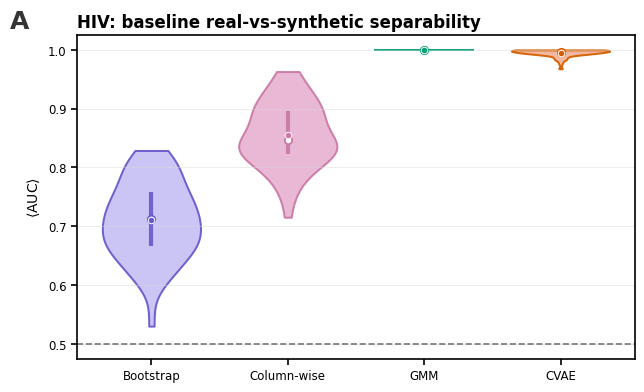

In [3]:
auc_runs = revision_cache.get_auc_runs(force=False)
selected_auc = auc_runs[(auc_runs["dataset"] == DATASET) & (auc_runs["method"] == METHOD)]
display(selected_auc["separability_auc"].describe().to_frame("RF origin AUC"))

fig, ax = plt.subplots(figsize=(7.2, 4.2))
figure2_auc._plot_auc_violin_panel(ax, auc_runs, DATASET, "A")
ax.set_title(f"{DATASET}: baseline real-vs-synthetic separability", loc="left", weight="bold")
plt.show()


In [4]:
datasets, dataset_summary = data_io.initialize_datasets()
data = datasets[DATASET]
y_real = np.asarray(data["y"], dtype=int)

# Use the exact shared Figure 4 generation path from the main notebook.
figure4_real, figure4_synthetic, figure4_feature_names = figure4_graphical_lasso._get_figure4_precision_inputs(
    seed=revision_config.SEED,
    cvae_epochs=revision_config.CVAE_EPOCHS,
)
X_real = np.asarray(figure4_real[DATASET], dtype=np.float64)
X_syn = np.asarray(figure4_synthetic[DATASET][METHOD], dtype=np.float64)
feature_names = list(figure4_feature_names[DATASET])
n0, n1 = class_counts(y_real)
y_syn = np.r_[np.zeros(n0, dtype=int), np.ones(n1, dtype=int)]

display(dataset_summary)
print(f"Selected comparison: {DATASET} / {METHOD}; real={X_real.shape}, synthetic={X_syn.shape}")


Epoch    1 | train loss=59.4345 recon=59.3622 kl=0.1446 | val loss=78.4132 recon=78.3381 kl=0.1501
Epoch   10 | train loss=55.0814 recon=54.5651 kl=1.0327 | val loss=75.1556 recon=74.4211 kl=1.4690
Epoch   20 | train loss=49.5437 recon=46.3646 kl=6.3583 | val loss=59.7132 recon=57.2741 kl=4.8782
Epoch   30 | train loss=37.0336 recon=35.2526 kl=3.5620 | val loss=55.3492 recon=52.8178 kl=5.0628
Epoch   40 | train loss=35.7443 recon=31.5312 kl=8.4264 | val loss=53.4445 recon=48.9844 kl=8.9201
Epoch   50 | train loss=33.3516 recon=29.9936 kl=6.7162 | val loss=48.4559 recon=44.0604 kl=8.7910
Epoch   60 | train loss=33.5782 recon=29.7126 kl=7.7312 | val loss=47.5115 recon=43.3358 kl=8.3514
Epoch   70 | train loss=25.4368 recon=21.6556 kl=7.5625 | val loss=49.1987 recon=44.7192 kl=8.9590
Epoch   80 | train loss=27.3788 recon=22.9788 kl=8.8000 | val loss=46.1841 recon=41.4502 kl=9.4678
Epoch   90 | train loss=26.5942 recon=21.7606 kl=9.6673 | val loss=46.5686 recon=41.9486 kl=9.2398
Epoch  100

,dataset,samples,features,class_0,class_1
0,HIV,91,63,23,68
1,Breast Cancer,569,30,212,357
2,Diabetes,768,8,500,268


Selected comparison: HIV / CVAE; real=(91, 63), synthetic=(91, 63)


## Reference 2: Graphical Lasso relationship errors

The first panel below is deliberately constrained to be apples-to-apples with the main notebook: it uses the same synthetic matrix, Graphical Lasso alpha, hierarchical feature order, edge threshold, four status categories, colors, and top-left matrix origin. Display index 1 means the first feature in the shared clustered order.

The second panel keeps that exact feature order but subdivides edges present in both graphs into `changed` and `reversed` categories. These categories describe the structural mismatch; the recovery intervention below uses the complete precision-implied dependence matrix rather than selecting individual displayed clusters or edges.

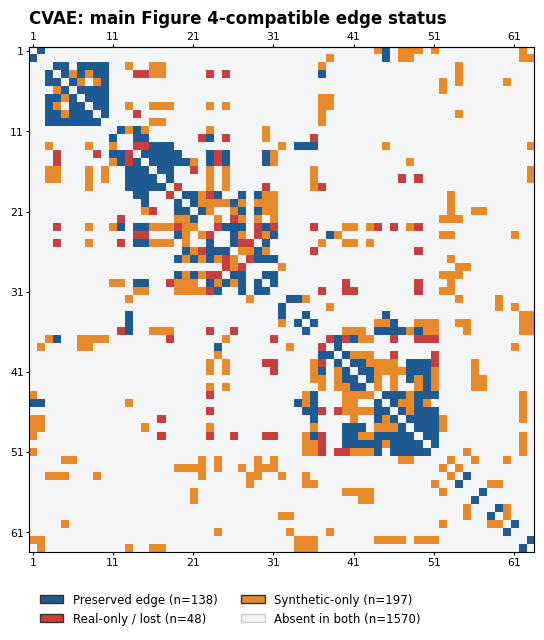

,count
edge status,
absent,1570
synthetic_only,197
preserved,79
changed,59
real_only,48


,i,j,feature_i,feature_j,category,real_partial,synthetic_partial,abs_partial_error,real_abs_strength,synthetic_abs_strength
0,46,47,V9_Saliva_IgAspike,V9_Saliva_IgARBD,changed,0.345428,0.106766,0.238662,0.345428,0.106766
1,40,42,V5_Saliva_IgAspike,V8_Saliva_IgAspike,real_only,0.234839,0.000000,0.234839,0.234839,0.000000
2,41,45,V5_Saliva_IgARBD,V8b_Saliva_IgARBD,synthetic_only,0.000000,0.202211,0.202211,0.000000,0.202211
3,17,27,V11_blood_IgGspike,V11_blood_IgGRBD,changed,0.195770,0.389544,0.193774,0.195770,0.389544
4,31,39,V5_Saliva_IgGRBD,V4_Saliva_IgARBD,changed,0.000003,0.192314,0.192312,0.000003,0.192314
5,40,44,V5_Saliva_IgAspike,V8b_Saliva_IgAspike,changed,0.012525,0.193601,0.181077,0.012525,0.193601
6,28,29,V4_Saliva_IgGspike,V4_Saliva_IgGRBD,real_only,0.166894,0.000000,0.166894,0.166894,0.000000
7,8,18,V1_blood_IgGspike,V1_blood_IgGRBD,changed,0.153595,0.319838,0.166243,0.153595,0.319838
8,54,55,IFNG_production,Il2_production,changed,0.153935,0.313941,0.160006,0.153935,0.313941
9,40,47,V5_Saliva_IgAspike,V9_Saliva_IgARBD,synthetic_only,0.000000,0.154945,0.154945,0.000000,0.154945


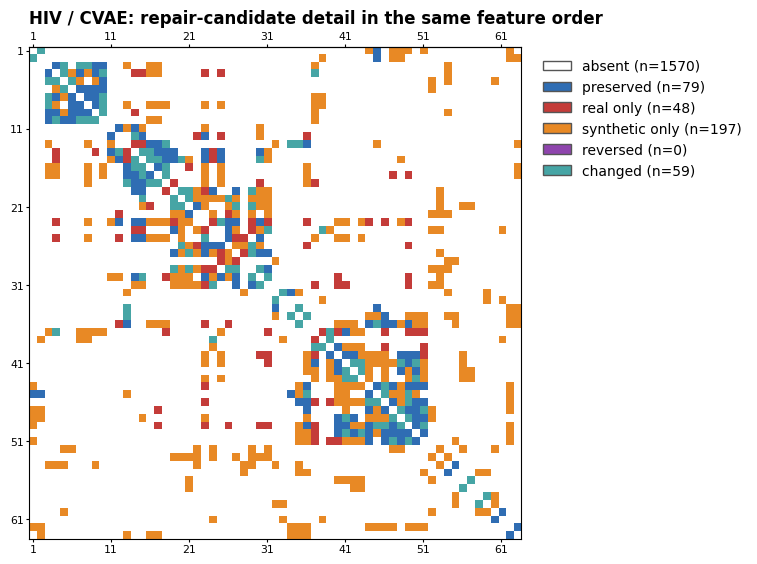

In [5]:
fig_reference, figure4_order = plot_figure4_compatible_edge_status(
    X_real,
    X_syn,
    feature_names,
    alpha=FIGURE4_ALPHAS[DATASET],
    method=METHOD,
)
plt.show()

edge_table_full = build_edge_discrepancy_table(
    X_real,
    X_syn,
    feature_names=feature_names,
    alpha=FIGURE4_ALPHAS[DATASET],
    changed_threshold=0.05,
)

display(edge_table_full["category"].value_counts().rename_axis("edge status").to_frame("count"))
display(edge_table_full[edge_table_full["category"].isin(ERROR_CATEGORIES)].head(20))
plot_edge_discrepancy_map(
    edge_table_full,
    feature_names,
    title=f"{DATASET} / {METHOD}: repair-candidate detail in the same feature order",
    order=figure4_order,
)
plt.show()


## Controlled structural recovery experiment

The intervention does not edit or rearrange the original CVAE rows. It generates a new comparison sample from CVAE's class-conditional empirical feature distributions while controlling the Gaussian-copula dependence matrix. At alignment strength 0, dependence comes from the synthetic Graphical Lasso fit. At alignment strength 1, dependence comes from the correctly feature-matched real Graphical Lasso fit. Intermediate values interpolate between them.

The feature-permuted control uses the same real dependence matrix with feature identities shuffled. This controls for imposing equally strong structure without imposing the correct feature relationships.

In [6]:
if experiment_cache.exists() and not FORCE_RECOMPUTE:
    with experiment_cache.open("rb") as handle:
        cached = pickle.load(handle)
    recovery_results = cached["recovery_results"]
    structures = cached["structures"]
    print(f"Loaded {experiment_cache.name}")
else:
    recovery_results, structures = run_structural_recovery_test(
        dataset_name=DATASET,
        method=METHOD,
        X_real=X_real,
        y_real=y_real,
        X_syn=X_syn,
        y_syn=y_syn,
        strengths=ALIGNMENT_STRENGTHS,
        copula_repeats=COPULA_REPEATS,
        auc_repeats=AUC_REPEATS,
        seed=revision_config.SEED,
    )
    with experiment_cache.open("wb") as handle:
        pickle.dump(
            {"recovery_results": recovery_results, "structures": structures},
            handle,
        )
    print(f"Wrote {experiment_cache.name}")


c:\Users\tonyt\Desktop\distinguishable_data\.venv\Lib\site-packages\sklearn\covariance\_graph_lasso.py:199: ConvergenceWarning: graphical_lasso: did not converge after 1000 iteration: dual gap: -1.663e-03
  warnings.warn(
c:\Users\tonyt\Desktop\distinguishable_data\.venv\Lib\site-packages\sklearn\covariance\_graph_lasso.py:199: ConvergenceWarning: graphical_lasso: did not converge after 1000 iteration: dual gap: -1.663e-03
  warnings.warn(
c:\Users\tonyt\Desktop\distinguishable_data\.venv\Lib\site-packages\sklearn\covariance\_graph_lasso.py:199: ConvergenceWarning: graphical_lasso: did not converge after 1000 iteration: dual gap: -2.138e-03
  warnings.warn(
c:\Users\tonyt\Desktop\distinguishable_data\.venv\Lib\site-packages\sklearn\covariance\_graph_lasso.py:199: ConvergenceWarning: graphical_lasso: did not converge after 1000 iteration: dual gap: -3.778e-03
  warnings.warn(
c:\Users\tonyt\Desktop\distinguishable_data\.venv\Lib\site-packages\sklearn\covariance\_graph_lasso.py:199: Conv

Wrote structural_recovery_v3_hiv_cvae.pkl


c:\Users\tonyt\Desktop\distinguishable_data\.venv\Lib\site-packages\sklearn\covariance\_graph_lasso.py:199: ConvergenceWarning: graphical_lasso: did not converge after 1000 iteration: dual gap: -4.525e-04
  warnings.warn(


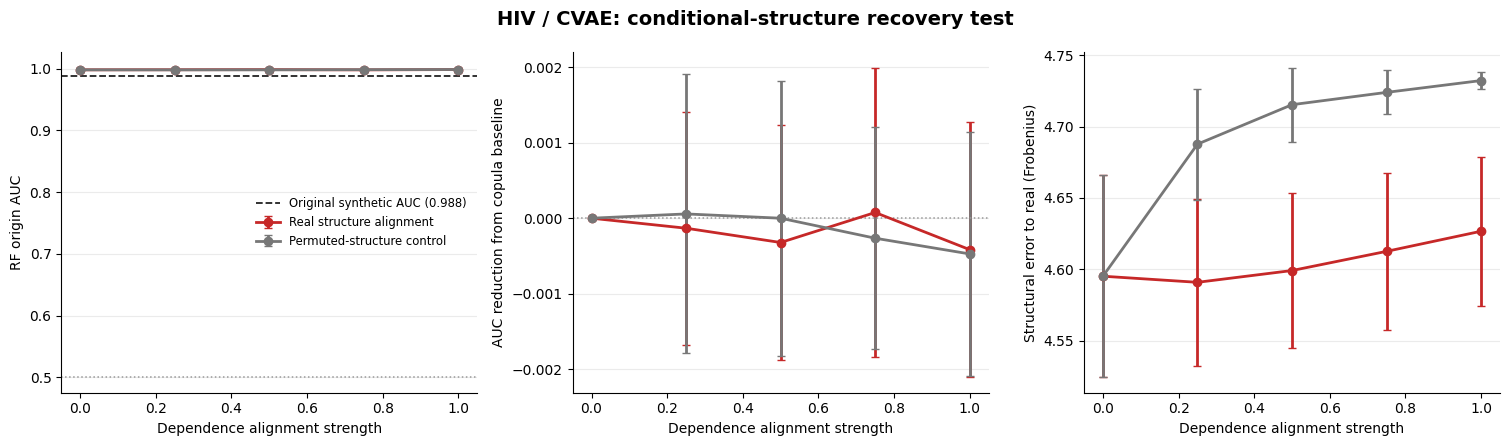

,dataset,method,condition,strength,mean_auc,sd_auc,mean_auc_reduction,sd_auc_reduction,mean_structural_error,sd_structural_error,mean_marginal_ks,max_marginal_ks,runs
0,HIV,CVAE,permuted_structure_control,0.00,0.998166,0.003093,0.000000,0.000000,4.595130,0.070874,0.139600,0.391304,50
1,HIV,CVAE,permuted_structure_control,0.25,0.998110,0.003588,0.000057,0.001846,4.687780,0.038971,0.140756,0.391304,50
2,HIV,CVAE,permuted_structure_control,0.50,0.998166,0.003502,0.000000,0.001822,4.715449,0.026044,0.139253,0.391304,50
3,HIV,CVAE,permuted_structure_control,0.75,0.998431,0.002843,-0.000265,0.001467,4.724090,0.015439,0.138913,0.347826,50
4,HIV,CVAE,permuted_structure_control,1.00,0.998639,0.002612,-0.000473,0.001612,4.732385,0.005938,0.137821,0.347826,50
5,HIV,CVAE,targeted_structure,0.00,0.998166,0.003093,0.000000,0.000000,4.595130,0.070874,0.139600,0.391304,50
6,HIV,CVAE,targeted_structure,0.25,0.998299,0.003161,-0.000132,0.001540,4.590845,0.058484,0.140039,0.347826,50
7,HIV,CVAE,targeted_structure,0.50,0.998488,0.003132,-0.000321,0.001558,4.599107,0.054450,0.140203,0.391304,50
8,HIV,CVAE,targeted_structure,0.75,0.998091,0.003725,0.000076,0.001918,4.612565,0.055284,0.138189,0.391304,50
9,HIV,CVAE,targeted_structure,1.00,0.998582,0.003219,-0.000416,0.001688,4.626675,0.052360,0.138443,0.391304,50


In [7]:
fig, recovery_summary = plot_structural_recovery(
    recovery_results,
    title=f"{DATASET} / {METHOD}: conditional-structure recovery test",
)
plt.show()
display(recovery_summary)


## Control and validity checks

Because the adjusted rows are newly sampled, finite-sample marginal distributions will not be numerically identical to the original CVAE columns. They are sampled from the same class-conditional empirical distributions. Kolmogorov-Smirnov statistics quantify the remaining sampling variation.

A convincing result requires three linked patterns: correctly aligned structure approaches the real structure, its AUC falls relative to the strength-0 copula baseline, and the feature-permuted control does not show the same AUC reduction.

In [8]:
validity_summary = recovery_summary[
    [
        "condition",
        "strength",
        "mean_structural_error",
        "mean_marginal_ks",
        "max_marginal_ks",
        "mean_auc",
        "mean_auc_reduction",
    ]
]
display(validity_summary)

full_alignment = recovery_summary[np.isclose(recovery_summary["strength"], 1.0)]
display(full_alignment.sort_values("condition"))


,condition,strength,mean_structural_error,mean_marginal_ks,max_marginal_ks,mean_auc,mean_auc_reduction
0,permuted_structure_control,0.00,4.595130,0.139600,0.391304,0.998166,0.000000
1,permuted_structure_control,0.25,4.687780,0.140756,0.391304,0.998110,0.000057
2,permuted_structure_control,0.50,4.715449,0.139253,0.391304,0.998166,0.000000
3,permuted_structure_control,0.75,4.724090,0.138913,0.347826,0.998431,-0.000265
4,permuted_structure_control,1.00,4.732385,0.137821,0.347826,0.998639,-0.000473
5,targeted_structure,0.00,4.595130,0.139600,0.391304,0.998166,0.000000
6,targeted_structure,0.25,4.590845,0.140039,0.347826,0.998299,-0.000132
7,targeted_structure,0.50,4.599107,0.140203,0.391304,0.998488,-0.000321
8,targeted_structure,0.75,4.612565,0.138189,0.391304,0.998091,0.000076
9,targeted_structure,1.00,4.626675,0.138443,0.391304,0.998582,-0.000416


,dataset,method,condition,strength,mean_auc,sd_auc,mean_auc_reduction,sd_auc_reduction,mean_structural_error,sd_structural_error,mean_marginal_ks,max_marginal_ks,runs
4,HIV,CVAE,permuted_structure_control,1.0,0.998639,0.002612,-0.000473,0.001612,4.732385,0.005938,0.137821,0.347826,50
9,HIV,CVAE,targeted_structure,1.0,0.998582,0.003219,-0.000416,0.001688,4.626675,0.052360,0.138443,0.391304,50


## What structure is being imposed?

The intervention uses the complete real precision-implied dependence matrix, not visually defined clusters and not a hand-selected list of edges. Feature ordering therefore has no role in the intervention. The permuted control retains the same matrix values and eigenstructure but assigns them to the wrong feature identities.

In [9]:
display(
    pd.DataFrame(
        {
            "original_feature_index": np.arange(1, len(feature_names) + 1),
            "feature_name": feature_names,
            "permuted_control_source_index": structures["permutation"] + 1,
        }
    )
)


,original_feature_index,feature_name,permuted_control_source_index
0,1,spikeProduction_D1D2,19
1,2,spikeDecay_D1D2,6
2,3,spikeProduction_D3,33
3,4,spikeDecay_D3,51
4,5,RBDProduction_D1D2,9
...,...,...,...
58,59,V9Neut,18
59,60,V7_ACE2,63
60,61,V8_ACE2,43
61,62,V8b_ACE2,40


## Decision rule

The hypothesis is supported for this dataset-generator pair only if:

- correctly aligned structure moves progressively closer to the real structure;
- RF-AUC decreases progressively from the strength-0 copula baseline;
- the AUC reduction exceeds the feature-permuted structural control; and
- synthetic class-conditional marginals remain close across alignment strengths.

If structural error decreases without a targeted AUC reduction, the correct conclusion is that the Graphical Lasso errors do not explain RF separability under this intervention. The remaining discriminator signal may instead be marginal, nonlinear, higher-order, or outside the Gaussian-copula representation.